In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from scipy import stats
from IPython.display import display, Math


### 1. Determinen intervalos de confianza empíricos para el supermercado ‘Santa Ana’ en cada mes, para significancias del 95% y del 99%.

In [16]:
# Cargo los datos del supermercado Santa Ana
file_path = "Datos_TP_final_23Co2025_a2325.xlsx"
santa_ana = pd.read_excel(file_path, sheet_name="Santa Ana")

santa_ana["Fecha"] = pd.to_datetime(santa_ana["Fecha"])

santa_ana["Mes"] = santa_ana["Fecha"].dt.month_name()

# Vista previa
santa_ana.head()

,Fecha,Ventas,Mes
0,2023-01-01,12812.879463,January
1,2023-01-02,15735.368502,January
2,2023-01-03,18809.948765,January
3,2023-01-04,19252.271266,January
4,2023-01-05,21417.000964,January


In [17]:
# Para calcular los intervalos de confianza, me baso en la tabla para obtener Z, dado que n > 30

Z_95 = 1.96
Z_99 = 2.575

resultados = []

# en este paso voy a recorrer todos los meses agrupados y les calculare a cada uno su intervalo de confianzaa para las significancias requeridas.
for mes, grupo in santa_ana.groupby("Mes"):
    ventas = grupo["Ventas"].values
    n = len(ventas)
    media = np.mean(ventas)
    s = np.std(ventas, ddof=1)
    
    # Calculo los Intervalos de confianza para 95% y 99% de significancia
    ic95_inf = media - Z_95 * s / np.sqrt(n)
    ic95_sup = media + Z_95 * s / np.sqrt(n)
    ic99_inf = media - Z_99 * s / np.sqrt(n)
    ic99_sup = media + Z_99 * s / np.sqrt(n)
    
    resultados.append([mes, media, ic95_inf, ic95_sup, ic99_inf, ic99_sup])

ic_df = pd.DataFrame(resultados, columns=["Mes", "Media", "IC_95_inf", "IC_95_sup", "IC_99_inf", "IC_99_sup"])

# para poder graficar correctamente, ordeno los meses
orden_meses = ["January","February","March","April","May","June","July",
               "August","September","October","November","December"]
ic_df["Mes"] = pd.Categorical(ic_df["Mes"], categories=orden_meses, ordered=True)
ic_df = ic_df.sort_values("Mes")

ic_df

,Mes,Media,IC_95_inf,IC_95_sup,IC_99_inf,IC_99_sup
4,January,17797.622233,16892.710207,18702.534258,16608.770974,18986.473491
3,February,19433.649375,18419.136267,20448.162483,18100.806899,20766.491851
7,March,22946.960058,22004.839053,23889.081063,21709.224553,24184.695563
0,April,20868.421745,19894.868249,21841.975242,19589.391003,22147.452487
8,May,22296.973416,21391.519477,23202.427355,21107.410205,23486.536626
6,June,23161.785200,22121.838789,24201.731611,21795.529073,24528.041327
5,July,22017.776351,20920.002611,23115.550090,20575.548096,23460.004605
1,August,23403.801946,22264.204655,24543.399238,21906.626934,24900.976959
11,September,22563.785813,21557.018698,23570.552928,21241.119833,23886.451794
10,October,23001.160527,22244.847442,23757.473613,22007.534917,23994.786138


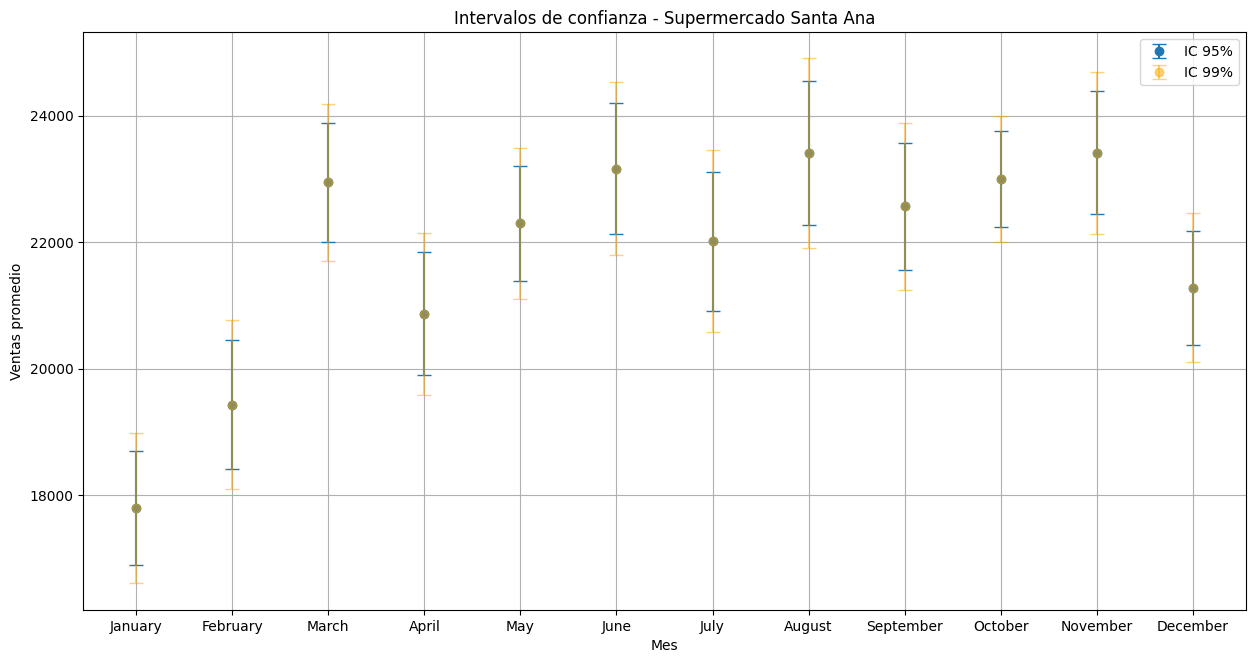

In [18]:
# Utilizo matplot para poder graficar y visualizar los intervalos de confianza por mes

plt.figure(figsize=(15,7.5))
plt.errorbar(ic_df["Mes"], ic_df["Media"],
             yerr=[ic_df["Media"] - ic_df["IC_95_inf"], ic_df["IC_95_sup"] - ic_df["Media"]],
             fmt='o', capsize=5, label='IC 95%')

plt.errorbar(ic_df["Mes"], ic_df["Media"],
             yerr=[ic_df["Media"] - ic_df["IC_99_inf"], ic_df["IC_99_sup"] - ic_df["Media"]],
             fmt='o', capsize=5, alpha=0.5, label='IC 99%', color='orange')

plt.title("Intervalos de confianza - Supermercado Santa Ana")
plt.xlabel("Mes")
plt.ylabel("Ventas promedio")
plt.legend()
plt.grid(True)
plt.show()


El gráfico muestra los intervalos de confianza al 95 % y 99 % para las ventas promedio mensuales del supermercado Santa Ana durante 2023. Se observa una estacionalidad marcada, con menores ventas en enero y febrero, coincidiendo con la temporada de vacaciones en Argentina, y un incremento sostenido a partir de marzo, alcanzando valores máximos entre junio y agosto. Luego, las ventas se mantienen relativamente estables hasta fin de año, con una leve caída en diciembre (que tambien coincide con el comienzo de temporada de vacaciones). La amplitud mayor de los intervalos al 99 % refleja una incertidumbre más alta, aunque en general los rangos son acotados, indicando consistencia en el comportamiento mensual. En conjunto, los resultados evidencian un patrón estacional predecible útil para la planificación comercial y de inventarios.

---

### 2.  Realicen pruebas ANOVA para determinar si las ventas esperadas de todas las tiendas son iguales o no, con significancia del 95%.

El objetivo del análisis es determinar si las **ventas promedio** de los cinco supermercados —*Santa Ana*, *La Floresta*, *Los Cedros*, *Palermo* y *Córdoba*— pueden considerarse **estadísticamente iguales**, o si existen diferencias significativas entre ellas.  

Para ello se aplico un **ANOVA de un factor (Análisis de Varianza)**.

Las hipótesis del contraste son:

- **Hipótesis nula ($H_0$):** todas las medias poblacionales de ventas son iguales.  

  $$
  H_0: \mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5
  $$

- **Hipótesis alternativa ($H_1$):** al menos una media es distinta.  

  $$
  H_1: \text{al menos una } \mu_i \neq \mu_j
  $$

El **nivel de significancia** adoptado es **α = 0.05 (95 % de confianza)**.  

El procedimiento calcula el **estadístico F**, definido como la razón entre la **variabilidad entre grupos** y la **variabilidad dentro de los grupos**:

$$
F = \frac{\text{Suma de cuadrados entre grupos} / (k - 1)}{\text{Suma de cuadrados dentro de los grupos} / (N - k)}
$$

Si el **valor p** asociado al estadístico F es menor o igual a 0.05, se **rechaza $H_0$**, concluyendo que no todas las medias son iguales. En cambio, si **p > 0.05**, no se cuenta con evidencia suficiente para afirmar diferencias significativas.

El código de ANOVA que se presenta a continuación implementa este procedimiento para evaluar las ventas entre los cinco supermercados.


In [19]:
# Cargo todas las hojas en un diccionario
sheets = ["Santa Ana", "La Floresta", "Los Cedros", "Palermo", "Córdoba"]
data = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in sheets}

for df in data.values():
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    
    
# Extraigo las ventas
ventas = [df["Ventas"].values for df in data.values()]

# ANOVA de un factor (ventas entre supermercados) use l el motodo f_oneway como vimos en el ejemplo de la clase
f_stat, p_value = stats.f_oneway(*ventas)

print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    display(Math(r"\text{Se rechaza } H_0: \text{ existen diferencias significativas entre las medias de ventas.}"))
else:
    display(Math(r"\text{No se rechaza } H_0: \text{ no hay evidencia suficiente para afirmar que las medias sean distintas.}"))


Estadístico F: 106.3388
Valor p: 0.0000


<IPython.core.display.Math object>

Con un nivel de significancia del 95 % (α = 0.05), se obtuvo un estadístico F = 106.34 y un p-valor$\approx$ 0.0000, por lo que se rechaza la hipótesis nula de igualdad de medias. Este resultado indica que existen diferencias estadísticamente significativas entre los niveles promedio de ventas de los supermercados, lo que sugiere que el desempeño comercial no es uniforme entre las tiendas. El procedimiento y la interpretación son consistentes con el método presentado en clase y en las diapositivas del módulo de ANOVA.

---

### 3. Identifiquen la tienda con mayor promedio de ventas y la tienda con menor promedio de ventas, y realicen una prueba de hipótesis para determinar si la diferencia entre ellas es distinta de cero o no.


En este punto buscamos **comparar las ventas promedio** entre las dos tiendas que presentan los **valores extremos** de desempeño: la que tiene el **mayor promedio de ventas** y la de  **menor promedio de ventas**.  

Tenemos que determinar si la diferencia observada entre ambas es **estadísticamente significativa** o si de podría atribuir simplemente al azar.

Para este caso selecciones la **prueba t de Student para dos muestras independientes**, dado que se trata de comparar las medias de dos grupos distintos, asumiendo que sus varianzas poblacionales son **desconocidas aunque no necesariamente iguales**.

Las hipótesis son las siguientes:

- **Hipótesis nula ($H_0$):** las medias poblacionales de las dos tiendas son iguales  
  $$
  H_0: \mu_1 = \mu_2 \quad \text{o equivalentemente} \quad \mu_1 - \mu_2 = 0
  $$

- **Hipótesis alternativa ($H_1$):** las medias poblacionales son diferentes  
  $$
  H_1: \mu_1 \neq \mu_2
  $$

Estamos hablando de una **prueba bilateral**, dado que estamos evaluando si las medias difieren en cualquier dirección (sin asumir cuál de las tiendas vende más).  
El **nivel de significancia** adoptado es **α = 0.05**, correspondiente a un **nivel de confianza del 95 %**.

Calculamos el estadístico de prueba *t*:

$$
t = \frac{(\bar{X}_1 - \bar{X}_2) - d_0}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}
$$

donde el término $d_0 = 0$ porque se está contrastando la igualdad entre medias.  
El estimador combinado de la varianza, $s_p^2$, se obtiene como:

$$
s_p^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}
$$

Una vez calculado el valor del estadístico *t* y su correspondiente **p-valor**, se toma la siguiente decisión:

- Si $p \leq \alpha$: se **rechaza $H_0$**, concluyendo que existe una diferencia significativa entre las medias.  
- Si $p > \alpha$: **no se rechaza $H_0$**, lo que indica que no hay evidencia suficiente para afirmar que las medias sean diferentes.

El procedimiento consiste en identificar las dos tiendas con los promedios extremos de ventas, extraer sus datos, aplicar la **prueba t de Student** y analizar el resultado para determinar si la diferencia entre ambas medias puede considerarse significativa desde el punto de vista estadístico.



In [20]:
# Calculo los promedios de ventas
promedios = {sheet: df["Ventas"].mean() for sheet, df in data.items()}

# Identifico tiendas con mayor y menor promedio
tienda_max = max(promedios, key=promedios.get)
tienda_min = min(promedios, key=promedios.get)

print(f"Tienda con mayor promedio: {tienda_max} (${promedios[tienda_max]:.2f})")
print(f"Tienda con menor promedio: {tienda_min} (${promedios[tienda_min]:.2f})")

# Extraigo los datos de ambas tiendas
ventas_max = data[tienda_max]["Ventas"]
ventas_min = data[tienda_min]["Ventas"]

# Prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(ventas_max, ventas_min, equal_var=False)

print(f"\nEstadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    display(Math(r"\text{Se rechaza } H_0: \text{ las medias son diferentes.}"))
else:
    display(Math(r"\text{No se rechaza } H_0: \text{ no hay evidencia suficiente para confirmar que las medias son diferentes.}"))

Tienda con mayor promedio: La Floresta ($21878.85)
Tienda con menor promedio: Palermo ($18076.52)

Estadístico t: 16.2952
Valor p: 0.0000


<IPython.core.display.Math object>

Del análisis realizado se observa que la tienda **La Floresta** presenta el mayor promedio de ventas con **21,878.85**, mientras que **Palermo** registra el menor promedio, con **18,076.52**.

Al aplicar la prueba **t de Student** para dos muestras independientes, se obtuvo un estadístico **t = 16.30** y un **p-valor$\approx$ 0.0000**, con un nivel de significancia del **5% (α = 0.05)**.

Dado que el valor p es mucho menor que 0.05, se rechaza la hipótesis nula (**$H_0$**) de igualdad de medias. Esto implica que la diferencia observada entre las ventas promedio de ambas tiendas no puede atribuirse al azar, sino que es estadísticamente significativa.

En términos prácticos, puede concluirse que **La Floresta** supera de manera consistente a **Palermo** en sus niveles de ventas promedio, reflejando un desempeño comercial superior. Este resultado es coherente con los hallazgos previos del análisis ANOVA, que ya había mostrado diferencias significativas entre los supermercados.